# QFT, Quantum Phase estimation and Shor Algorithm

## Quantum Fourier transform

Tasks.
* Implement QFT of 5 qubits.
* Apply QFT to following states { $|0\rangle$, $|17\rangle$, $|31\rangle$ } simulate and plot the statevector using the Bloch sphere

https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/quantum-phase-estimation#1-introduction


In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Sampler

from numpy import pi

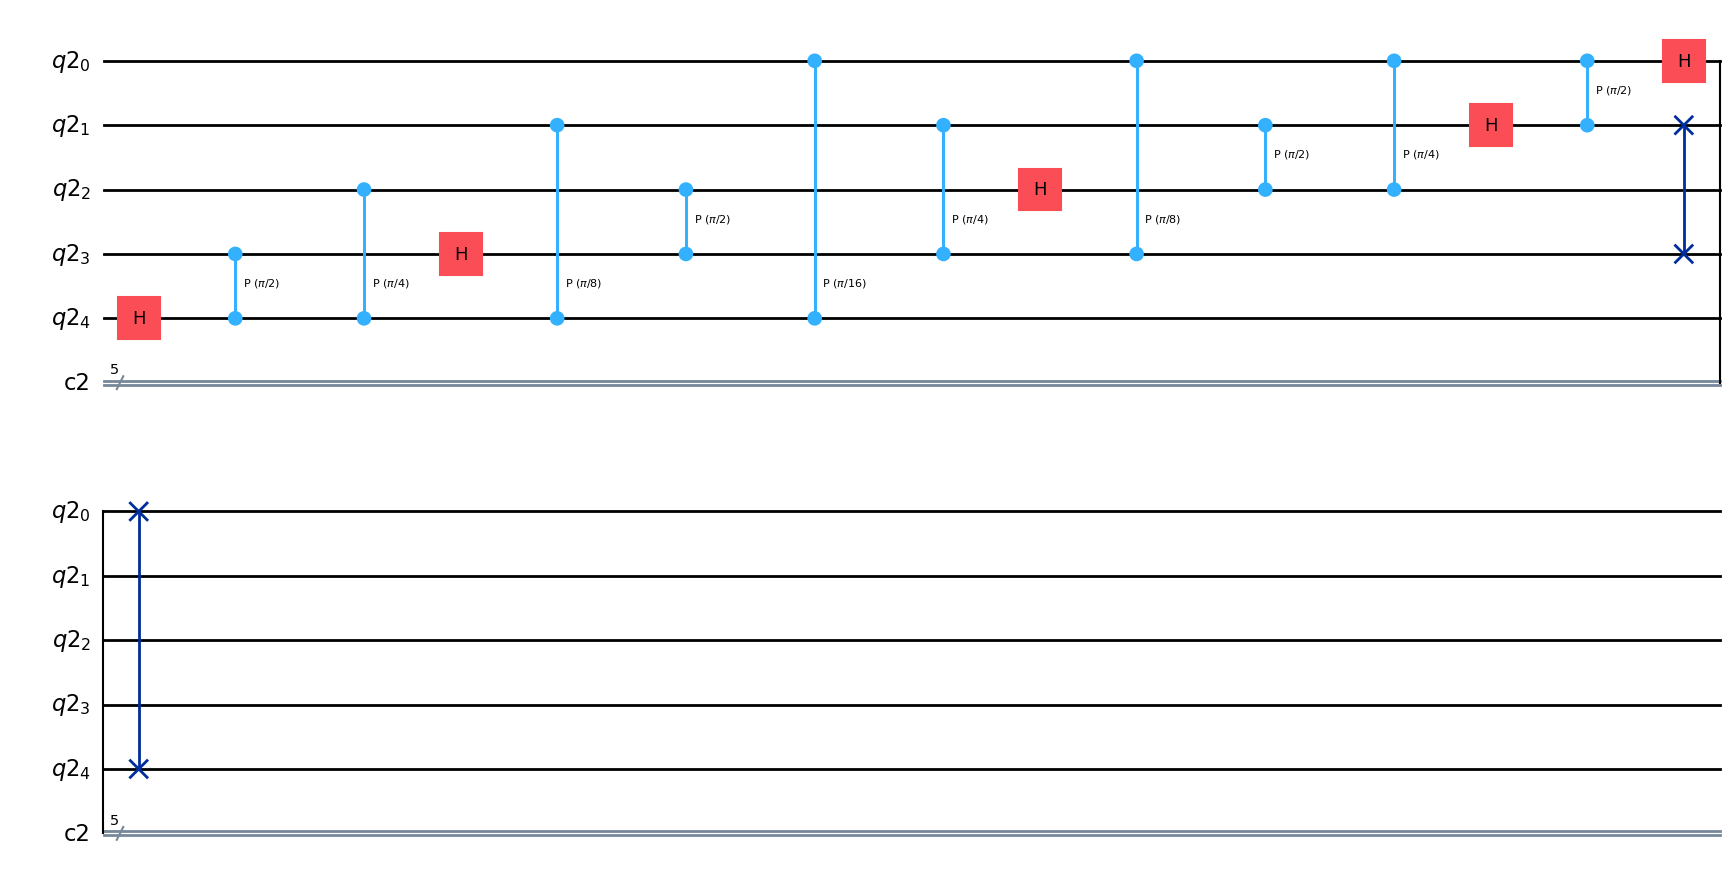

In [5]:
# Prepare for 5 qubits circuit - exercise 1

from qiskit import QuantumCircuit
from math import pi

def add_qft_5(qc):
    qc.h(4)
    qc.cp(pi / 2, 3, 4)
    qc.cp(pi / 4, 2, 4)
    qc.cp(pi / 8, 1, 4)
    qc.cp(pi / 16, 0, 4)

    qc.h(3)
    qc.cp(pi / 2, 2, 3)
    qc.cp(pi / 4, 1, 3)
    qc.cp(pi / 8, 0, 3)

    qc.h(2)
    qc.cp(pi / 2, 1, 2)
    qc.cp(pi / 4, 0, 2)

    qc.h(1)
    qc.cp(pi / 2, 0, 1)

    qc.h(0)

    qc.swap(0, 4)
    qc.swap(1, 3)

    return qc

qr = QuantumRegister(5)
cr = ClassicalRegister(5)
qc = QuantumCircuit(qr, cr)
qc_qft = add_qft_5(qc)
qc_qft.draw(output="mpl")



STATE |0>


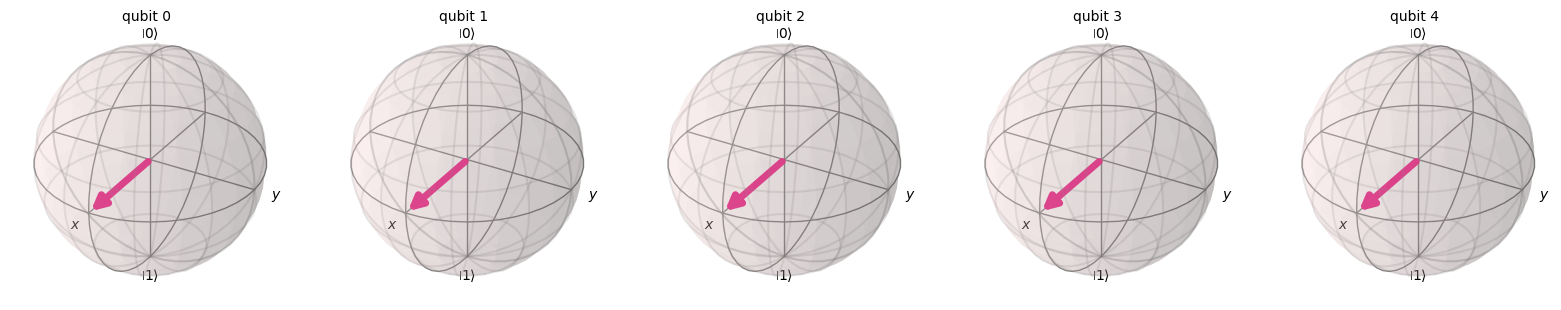

STATE |17>


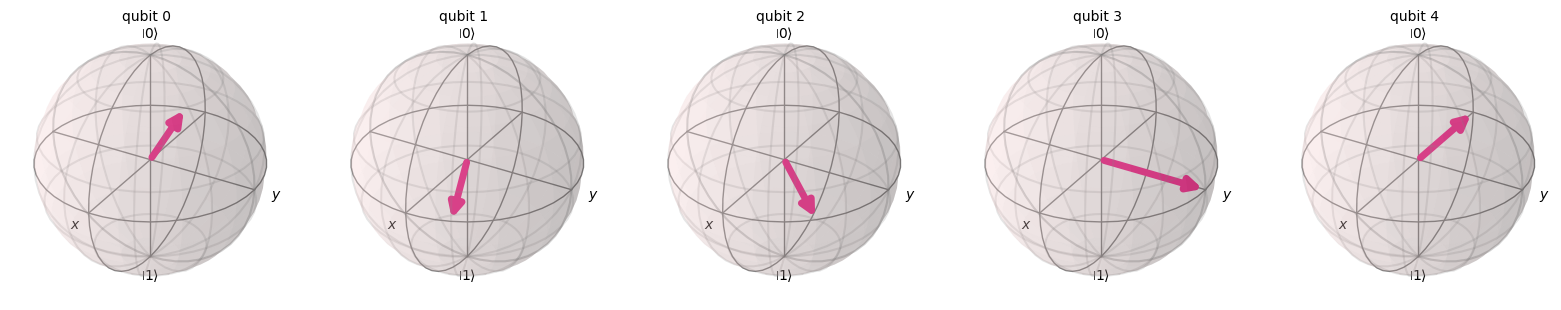

STATE |31>


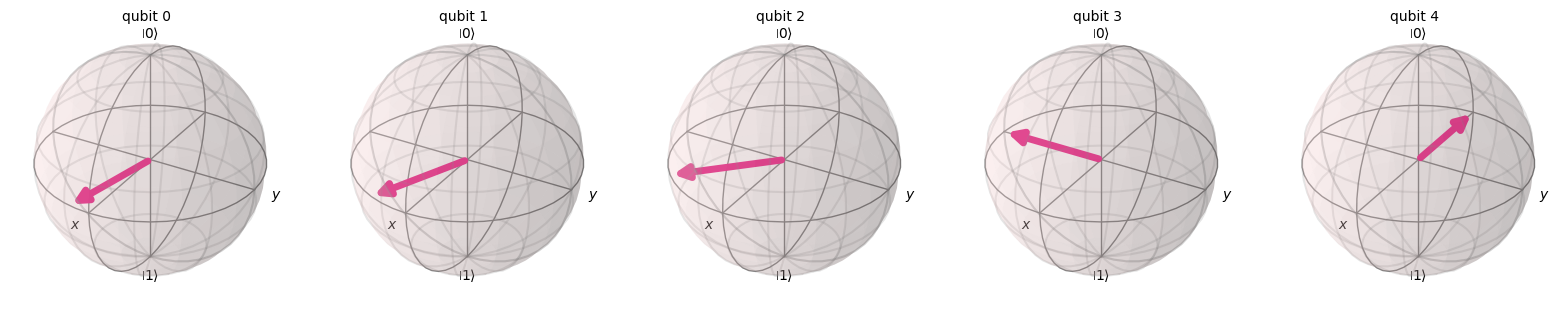

In [10]:
#now we simulate for |0>, |17>, and |31>

qc1 = QuantumCircuit(5) #|0>
qc2 = QuantumCircuit(5) #|17>
qc2.x(0)
qc2.x(4)
qc3 = QuantumCircuit(5) #|31>
qc3.x(0)
qc3.x(1)
qc3.x(2)
qc3.x(3)
qc3.x(4)

qc1.barrier()
qc2.barrier()
qc3.barrier()

qc1_qft = add_qft_5(qc1)
qc2_qft = add_qft_5(qc2)
qc3_qft = add_qft_5(qc3)

print("STATE |0>")
statevector1 = Statevector(qc1_qft)
display(plot_bloch_multivector(statevector1))

print("STATE |17>")
statevector2 = Statevector(qc2_qft)
display(plot_bloch_multivector(statevector2))

print("STATE |31>")
statevector3 = Statevector(qc3_qft)
display(plot_bloch_multivector(statevector3))



## Quantum Phase estimation

Task:
Implement quantum phase estimation algorithm (for ideal and noisy quantum simulator) for arbitrary searched phase $\theta$ following tutorial:

https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/quantum-phase-estimation

1. First consider phases for which $2^n \cdot \theta$ is an integer number (e.g. $\theta=1/8, \theta=3/8, \theta=5/8$), where n is the number of qubits in the counting register.

2. Next, consider phases for which $2^n \cdot \theta$ is not an integer (e.g. $\theta=1/3, \theta=1/5, \theta=1/7$). ***Show the acuurancy of estimating phase $\theta$ improves with increasing number of qubits  in the counting register.***

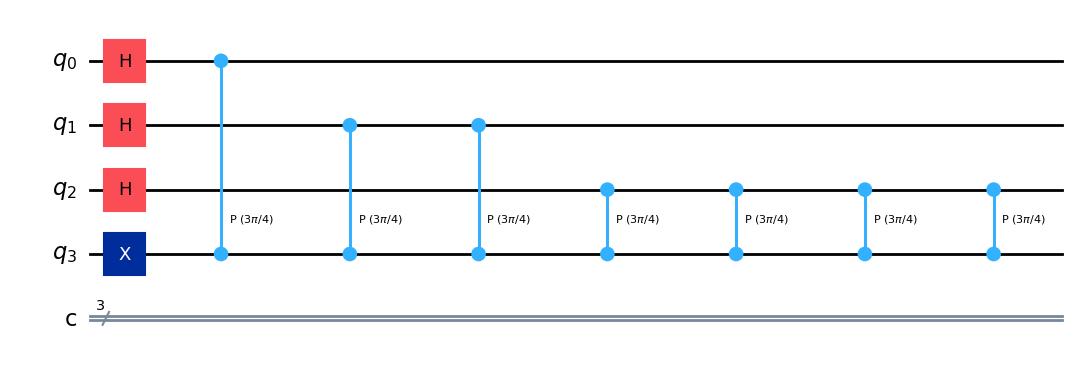

C:\Users\kacpe\AppData\Local\Temp\ipykernel_25436\2649937739.py:19: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qpe.append(QFT(3, inverse=True), [0, 1, 2])


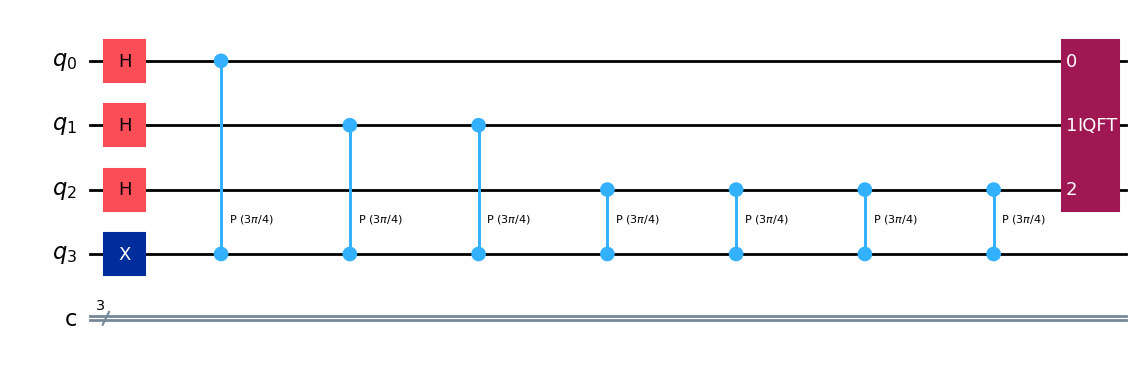

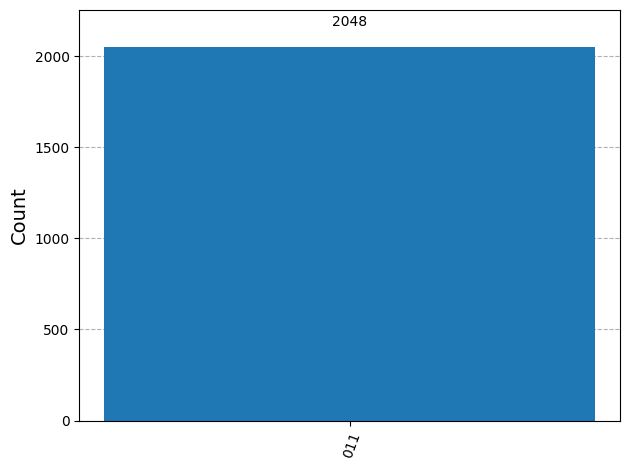

In [14]:


qpe = QuantumCircuit(4, 3)
qpe.x(3)
qpe.draw(output="mpl")

for qubit in range(3):
    qpe.h(qubit)
qpe.draw(output="mpl")

repetitions = 1
for counting_qubit in range(3):
    for i in range(repetitions):
        qpe.cp(3*pi / 4, counting_qubit, 3)  # This is C-U
    repetitions *= 2
display(qpe.draw(output="mpl"))

from qiskit.circuit.library import QFT

# Apply inverse QFT
qpe.append(QFT(3, inverse=True), [0, 1, 2])
display(qpe.draw(output="mpl"))


for n in range(3):
    qpe.measure(n, n)
qpe.draw(output="mpl")



aer_sim = AerSimulator()
shots = 2048

pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
t_qpe = pm.run(qpe)

sampler = Sampler(mode=aer_sim)
job = sampler.run([t_qpe], shots=shots)
result = job.result()
answer = result[0].data.c.get_counts()

plot_histogram(answer)

## Shor Algorithm

### Implement Shor alghoritm (for ideal and noisy quantum simulator) for factoring number N=35, 
1. Find all the positive integers $a$ of the set $Z^*$; $a\in Z^*$, such that gcd(z, N) == 1.
2. Find periods of the all ellements of $Z^*$
3. For selected $a$ plot $a^x($mod $N)$ as a function of x, e.g. for a=9, N=55,
   <img src="attachment:967f0d90-7bd6-4191-828a-a42e2a56818d.png" width="700">
   
5. List in the table all a and r for given N, e.g. for N=55:
   <img src="attachment:04d6e859-cf13-4826-89e8-16d0dcc974a8.png" width="700">
6. Pick up few diffrerent values of $a$ for implementation of Shor alghoritm with QPHE approach
7. Try to impement Shor alghoritm for arbitrary N let's say N<100: N={4, 6, 9, 10, 14, 15, 21, 22, 25, 26, 33, 34, 35, 38, 39, 46, 49, 51, 57, 58, 62, 65, 69, 74, 77, 82, 85, 86, 87, 91, 93, 94, 95.}, This will require aplication of U gate which corresponds to permitations. You can define U operator using Operator class and its matrix representation. Than you have to add it to a quantum corcuit.


Hints in: https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/shor.ipynb 
